# Introduccion

Dataset: (https://www.unb.ca/cic/datasets/ids-2017.html). 

NOTA: descargar la version normal, la ML-Ready tiene caracteristicas eliminadas. Si eso se puede hacer una comparacion de rendimiento entre los dos datasets.

# Pasos (Analisis Exploratorio)
1. Identificar __caracteristicas que puedan producir sesgos__.
2. Identificar __caracteristicas categoricas__. Es necesario darles una codificación numérica, para ello se pueden emplear las estrategias de codificación más habituales (codificación simple, ordinal, One-Hot-Encoding…). Justificar la decisión adoptada.
3. __Grafica de clases y analizar el desbalanceo__. Teniendo en cuenta clasificación binaria como multiclase.
4. __Top 10 caracteristicas mas y menos importantes__. Usando PCA, t-SNE, UMAP...
5. __Matriz de correlación del dataset__
   1. Características derivadas de la misma variable tienen alta correlación.
   2. Ciertas características dependen linealmente del tamaño de paquetes del flujo.
   3. Identificar características correspondientes a estos casos.

## Importar el dataset y dependencias

Crear el venv (Python 3.11) con las dependencias del requirements.txt:
```bash
%python -m venv venv
%pip install -r requirements.txt
```

El dataset descomprimido son unos 1.2Gb, podriamos subirlo a GitHub, pero dejo el .zip y ya lo descomprimis. 

In [ ]:
import glob
import os
import pandas as pd
import numpy as np

FOLDER_PATH = 'TrafficLabelling'
all_files = sorted(glob.glob(os.path.join(FOLDER_PATH, "*.csv")))

dfs = []

for file_path in all_files:
    temp = pd.read_csv(file_path, encoding='latin-1')
    temp.columns = temp.columns.str.strip()
    
    # Guardamos el fichero de origen para no perder trazabilidad
    temp["source_file"] = os.path.basename(file_path)
    dfs.append(temp)

df = pd.concat(dfs, ignore_index=True)

# Normalizar etiquetas raras
df['Label'] = df['Label'].replace({
    'Web Attack  XSS': 'Web Attack - XSS',
    'Web Attack  Sql Injection': 'Web Attack - Sql Injection',
    'Web Attack  Brute Force': 'Web Attack - Brute Force'
})

print(f"Shape inicial del dataset completo: {df.shape}")
print("\nClases únicas antes de limpiar:")
print(df['Label'].unique())

# Limpiar filas con Label nula
null_labels = df['Label'].isna().sum()
print(f"\nFilas con Label nula: {null_labels}")

if null_labels > 0:
    df = df.dropna(subset=['Label']).copy()

print(f"\nShape tras limpiar Label nula: {df.shape}")
print("\nClases únicas finales:")
print(sorted(df['Label'].unique()))

/tmp/ipykernel_46500/4002772799.py:12: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  temp = pd.read_csv(file_path, encoding='latin-1')


Shape inicial del dataset completo: (3119345, 86)

Clases únicas antes de limpiar:
<StringArray>
[                    'BENIGN',                       'DDoS',
                   'PortScan',                        'Bot',
               'Infiltration',   'Web Attack - Brute Force',
           'Web Attack - XSS', 'Web Attack - Sql Injection',
                          nan,                'FTP-Patator',
                'SSH-Patator',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed']
Length: 16, dtype: str

Filas con Label nula: 288602

Shape tras limpiar Label nula: (2830743, 86)

Clases únicas finales:
['BENIGN', 'Bot', 'DDoS', 'DoS GoldenEye', 'DoS Hulk', 'DoS Slowhttptest', 'DoS slowloris', 'FTP-Patator', 'Heartbleed', 'Infiltration', 'PortScan', 'SSH-Patator', 'Web Attack - Brute Force', 'Web Attack - Sql Injection', 'Web Attack - XSS']


Ahora generamos un dataset completo que contenga todos los datasets y aplicamos el analisis exploratorio al conjunto completo de datasets. No estoy seguro de si tendria que se cada dataset por separado para mantener algun tipo de temporalidad. Pero inicialmente vamos a aplicar un analisis y preprocesado al conjunto completo.  

In [3]:
import glob, os
FOLDER_PATH = 'TrafficLabelling'

# Leemos todos los datasets y los concatenamos en un solo DataFrame
all_files = glob.glob(os.path.join(FOLDER_PATH, "*.csv"))

# Tenemos que usar un encoding especifico por el formato CIC-IDS-2017, sino da error al leer los archivos
df = pd.concat((pd.read_csv(f, encoding='latin-1') for f in all_files), ignore_index=True)
df.columns = df.columns.str.strip()  # Limpiar nombres de columnas para simplicar el procesado

# Hay unos caracteres raros , que tenemos que reemplazar por -
df['Label'] = df['Label'].replace({
    'Web Attack  XSS': 'Web Attack - XSS',
    'Web Attack  Sql Injection': 'Web Attack - Sql Injection',
    'Web Attack  Brute Force': 'Web Attack - Brute Force'
})

# El shape final es de 3.119.345 filas X 85 columnas
print(f"Shape del dataset completo: {df.shape}")
print(f"\nClases únicas:")
print(df['Label'].unique())

/tmp/ipykernel_46500/1870038621.py:8: DtypeWarning: Columns (0: Flow ID, 1:  Source IP, 2:  Destination IP, 3:  Timestamp, 4:  Label) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.concat((pd.read_csv(f, encoding='latin-1') for f in all_files), ignore_index=True)


Shape del dataset completo: (3119345, 85)

Clases únicas:
<StringArray>
[                    'BENIGN',              'DoS slowloris',
           'DoS Slowhttptest',                   'DoS Hulk',
              'DoS GoldenEye',                 'Heartbleed',
                'FTP-Patator',                'SSH-Patator',
   'Web Attack - Brute Force',           'Web Attack - XSS',
 'Web Attack - Sql Injection',                          nan,
               'Infiltration',                        'Bot',
                       'DDoS',                   'PortScan']
Length: 16, dtype: str


In [4]:
# Para simplicar el analisis posterior guardamos un las cols y la distribucion de clases en un txt
with open('cols_labels.txt', 'w', encoding='utf-8') as f:
    f.write("Columnas del dataset:\n")
    for col in df.columns:
        f.write(f"{col}\n")
    f.write("\n\nDistribucion de clases:\n")
    if 'Label' in df.columns:
        f.write(df['Label'].value_counts().to_string())
        f.write("\n\nPorcentaje de cada clase:\n")
        f.write((df['Label'].value_counts(normalize=True) * 100).to_string())

# Caracteristicas que puedan producir sesgos

La verdad no se que poner aqui porque no se que puede producir sesgos en esto.

# Caracteristicas categoricas

In [5]:
# Identificamos las columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("Columnas categóricas detectadas:")
for col in categorical_cols:
    print("-", col)

# Decisión de tratamiento de características categóricas:

# - Flow ID, Source IP y Destination IP: No se codifican con one-hot debido a su alta cardinalidad
#   (miles de valores únicos) que causaría "curse of dimensionality" y riesgo de overfitting.
#   Estas características son identificadores de flujo, no predictores útiles para el modelo.

# - Timestamp: Ya transformada a datetime. Se extraerán variables temporales derivadas (hora, día).

# - Label: Se trata como variable objetivo (clasificación multi-clase con 15 clases).

# - label_binary: Variable objetivo alternativa para clasificación binaria (BENIGN vs ATTACK).

Columnas categóricas detectadas:
- Flow ID
- Source IP
- Destination IP
- Timestamp
- Label


/tmp/ipykernel_46500/2184022977.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


In [6]:
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Convertir timestamp a datetime para análisis
df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")

# Extraer rasgos temporales útiles
df["hour"] = df["Timestamp"].dt.hour
df["day_of_week"] = df["Timestamp"].dt.dayofweek

# Objetivo binario
df["label_binary"] = np.where(df["Label"] == "BENIGN", "BENIGN", "ATTACK")

# Objetivo multiclase codificado
label_encoder = LabelEncoder()
df["label_multiclass_encoded"] = label_encoder.fit_transform(df["Label"])

print("Clases multiclase codificadas:")
for cls, idx in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{idx}: {cls}")

Clases multiclase codificadas:
0: BENIGN
1: Bot
2: DDoS
3: DoS GoldenEye
4: DoS Hulk
5: DoS Slowhttptest
6: DoS slowloris
7: FTP-Patator
8: Heartbleed
9: Infiltration
10: PortScan
11: SSH-Patator
12: Web Attack - Brute Force
13: Web Attack - Sql Injection
14: Web Attack - XSS
15: nan


In [7]:
print("Columnas añadidas para análisis:")
print("- hour")
print("- day_of_week")
print("- label_binary")
print("- label_multiclass_encoded")

print(f"\nShape actual del dataset: {df.shape}")
print(f"Número total de columnas: {df.shape[1]}")

# En esta fase NO eliminamos todavía Flow ID, IPs o Timestamp:
# las conservamos para el análisis exploratorio y justificamos su exclusión más adelante en el modelado.

Columnas añadidas para análisis:
- hour
- day_of_week
- label_binary
- label_multiclass_encoded

Shape actual del dataset: (3119345, 89)
Número total de columnas: 89


# Grafica de clases y analizar el desbalanceo

In [8]:
#import matplotlib.pyplot as plt

# Grafica de clases CON BENIGN
#class_counts = df[['Label_BENIGN', 'Label_Bot', 'Label_DDoS', 'Label_DoS GoldenEye', 
#                   'Label_DoS Hulk', 'Label_DoS Slowhttptest', 'Label_DoS slowloris', 
#                   'Label_FTP-Patator', 'Label_Heartbleed', 'Label_Infiltration', 
#                   'Label_PortScan', 'Label_SSH-Patator', 'Label_Web Attack - Brute Force', 
#                   'Label_Web Attack - Sql Injection', 'Label_Web Attack - XSS']].sum()

# Descendente
#class_counts = class_counts.sort_values(ascending=False)

#fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# CON BENIGN
#class_counts.plot(kind='bar', ax=ax1, color='skyblue')
#ax1.set_title('Distribución de Clases (CON BENIGN)', fontsize=12, fontweight='bold')
#ax1.set_xlabel('Clases')
#ax1.set_ylabel('Número de Ejemplares')
#ax1.tick_params(axis='x', rotation=45)

# SIN BENIGN
#class_counts_sin_benign.plot(kind='bar', ax=ax2, color='coral')
#ax2.set_title('Distribución de Clases (SIN BENIGN)', fontsize=12, fontweight='bold')
#ax2.set_xlabel('Clases')
#ax2.set_ylabel('Número de Ejemplares')
#ax2.tick_params(axis='x', rotation=45)

#plt.tight_layout()
#plt.show()

# Stats de la distribucion de clases
#print("Distribución de clases:")
#print(class_counts)
#print(f"\nPorcentaje de BENIGN: {(class_counts['Label_BENIGN'] / class_counts.sum() * 100):.2f}%")
#print(f"\nDistribución sin BENIGN:")
#print(class_counts_sin_benign)
#print(f"\nPorcentaje de ataques (sin BENIGN): {(class_counts_sin_benign.sum() / class_counts.sum() * 100):.2f}%")

# Porcentaje de cada clase
#print(f"\nPorcentaje de cada clase:")
#class_percentages = (class_counts / class_counts.sum() * 100)
#for label, percentage in class_percentages.items():
#    print(f"{label}: {percentage:.2f}%")

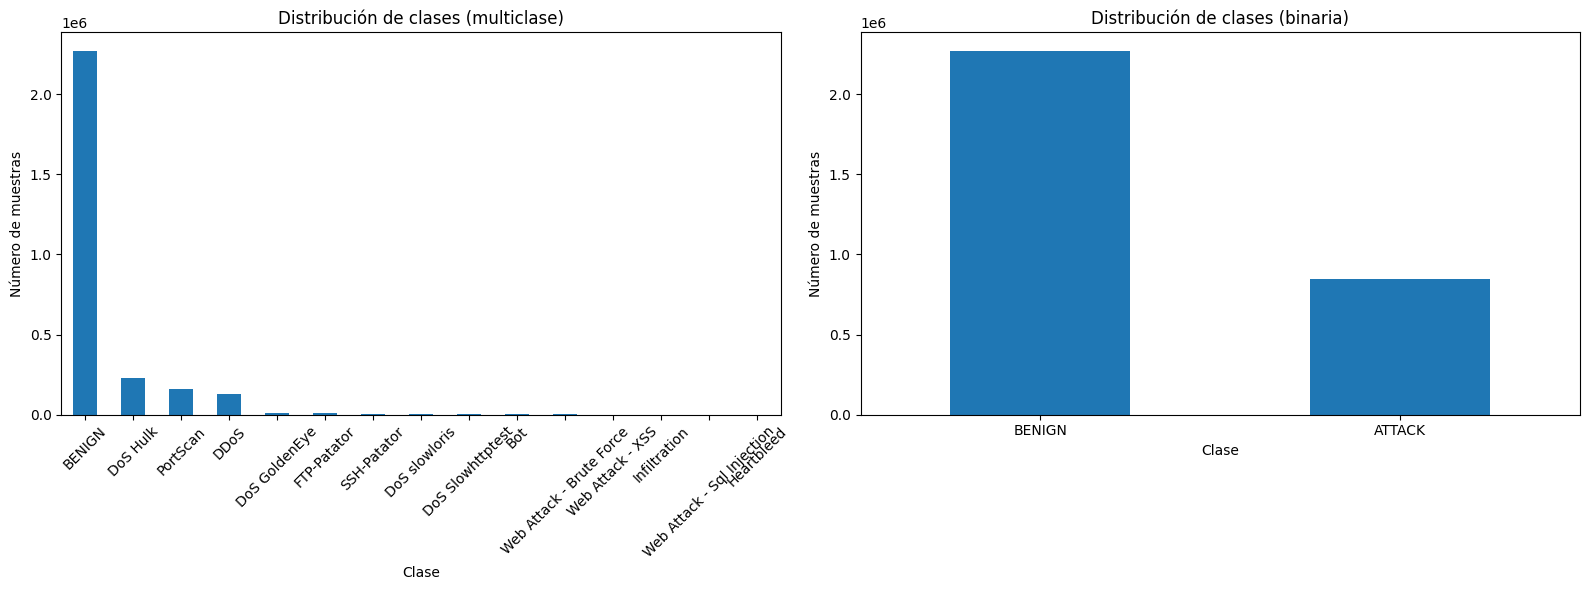

Distribución multiclase:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

Porcentajes multiclase:
Label
BENIGN                        72.87
DoS Hulk                       7.41
PortScan                       5.09
DDoS                           4.10
DoS GoldenEye                  0.33
FTP-Patator                    0.25
SSH-Patator                    0.19
DoS slowloris                  0.19
DoS Slowhttptest               0.18
Bot               

In [9]:
import matplotlib.pyplot as plt

# Distribución multiclase
class_counts_multi = df["Label"].value_counts()

# Distribución binaria
class_counts_binary = df["label_binary"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Multiclase
class_counts_multi.plot(kind="bar", ax=axes[0])
axes[0].set_title("Distribución de clases (multiclase)")
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("Número de muestras")
axes[0].tick_params(axis="x", rotation=45)

# Binaria
class_counts_binary.plot(kind="bar", ax=axes[1])
axes[1].set_title("Distribución de clases (binaria)")
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Número de muestras")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("Distribución multiclase:")
print(class_counts_multi)

print("\nPorcentajes multiclase:")
print((class_counts_multi / len(df) * 100).round(2))

print("\nDistribución binaria:")
print(class_counts_binary)

print("\nPorcentajes binarios:")
print((class_counts_binary / len(df) * 100).round(2))

# Top 10 caracteristicas mas y menos importante

Probamos tanto con PCA como con t-SNE y UMAP.

In [10]:
# Hay que realizar una limpieza previa para poder usar PCA y t-SNE
#from sklearn.manifold import TSNE
#from sklearn.preprocessing import StandardScaler
#import matplotlib.pyplot as plt
#import numpy as np
#import pandas as pd

# Separar features y labels
#label_cols = [col for col in df.columns if col.startswith('Label_')]
#feature_cols = [col for col in df.columns if not col.startswith('Label_')]

#X = df[feature_cols].copy()
#y = df[label_cols].copy()

# Quedarnos solo con columnas numéricas (evita errores con IP/Flow ID/Timestamp)
#X = X.select_dtypes(include=[np.number])

# Limpiar inf/-inf y NaN
#X = X.replace([np.inf, -np.inf], np.nan)
#valid_idx = X.dropna().index
#X = X.loc[valid_idx]
#y = y.loc[valid_idx]

#print(f"Shape limpio: {X.shape}")

# Usamos un muestreo ya que son 3 millones de filas, con 50.000 tarda 2min aprox
#max_samples = 50000
#if len(X) > max_samples:
#    sample_idx = X.sample(n=max_samples, random_state=42).index
#    X = X.loc[sample_idx]
#    y = y.loc[sample_idx]
#    print(f"Usando muestra de {max_samples} filas para t-SNE")

# Escalado
#scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)

In [11]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Columnas que no deben entrar como features directas
cols_to_exclude = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "Label",
    "label_binary",
    "source_file"
]

X = df.drop(columns=cols_to_exclude, errors="ignore").copy()
X = X.select_dtypes(include=[np.number])

# Limpiar inf/-inf y NaN
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how="all")

valid_idx = X.dropna().index
X = X.loc[valid_idx].copy()

# Targets alineados
y_multi = df.loc[valid_idx, "Label"].copy()
y_multi_encoded = df.loc[valid_idx, "label_multiclass_encoded"].copy()
y_binary = df.loc[valid_idx, "label_binary"].copy()

print(f"Shape limpio de X: {X.shape}")
print(f"Shape de y_multi: {y_multi.shape}")

# Muestreo para t-SNE
max_samples = 50000
if len(X) > max_samples:
    sample_idx = X.sample(n=max_samples, random_state=42).index
    X_tsne_input = X.loc[sample_idx]
    y_tsne = y_multi.loc[sample_idx]
    print(f"Usando muestra de {max_samples} filas para t-SNE")
else:
    X_tsne_input = X
    y_tsne = y_multi

# Escalado
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_tsne_scaled = scaler.fit_transform(X_tsne_input)

Shape limpio de X: (2298395, 83)
Shape de y_multi: (2298395,)
Usando muestra de 50000 filas para t-SNE


In [14]:
# Definir constantes para evitar duplicación de literales
#TSNE_1_LABEL = 't-SNE 1'
#TSNE_2_LABEL = 't-SNE 2'

# Ejecutar t-SNE con los datos escalados de la muestra
#tsne = TSNE(
#    n_components=2,
#    random_state=42,
#    perplexity=30,
#    max_iter=1000,
#    learning_rate='auto',
#    init='random',
#    verbose=1
#)

#X_tsne = tsne.fit_transform(X_tsne_scaled)

# Convertir etiquetas categóricas a códigos numéricos para colorear
#y_class = pd.Categorical(y_tsne).codes
#class_names = pd.Categorical(y_tsne).categories

# Crear figura con dos subgráficas
#fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfica 1: Scatter plot coloreado por clase
#scatter = axes[0].scatter(
#    X_tsne[:, 0], X_tsne[:, 1],
#    c=y_class, cmap='tab20', alpha=0.6, s=12, edgecolors='none'
#)

#axes[0].set_title('t-SNE: Visualización de clases')
#axes[0].set_xlabel(TSNE_1_LABEL)
#axes[0].set_ylabel(TSNE_2_LABEL)
#axes[0].grid(True, alpha=0.3)
#plt.colorbar(scatter, ax=axes[0], label='Clase')

# Gráfica 2: Mapa de densidad con hexbin
#axes[1].hexbin(X_tsne[:, 0], X_tsne[:, 1], gridsize=35, cmap='YlOrRd', mincnt=1)
#axes[1].set_title('t-SNE: Densidad (hexbin)')
#axes[1].set_xlabel(TSNE_1_LABEL)
#axes[1].set_ylabel(TSNE_2_LABEL)

#plt.tight_layout()

# Crear leyenda manual con los nombres de las clases presentes
#handles, _ = scatter.legend_elements()
#unique_classes = np.unique(y_class)
#legend_labels = [class_names[i] for i in unique_classes]

#axes[0].legend(
#    handles,
#    legend_labels,
#    title="Clases",
#    loc="upper right",
#    fontsize="small"
#)

#plt.show()

# Imprimir distribución de clases en la muestra usada
#print("\nDistribución de clases (muestra usada):")
#for i, class_name in enumerate(class_names):
#    count = (y_class == i).sum()
#    print(f"  {class_name}: {count}")

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.020s...
[t-SNE] Computed neighbors for 50000 samples in 6.428s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000 / 50000
[t-SNE] Computed conditional probabilities for sam

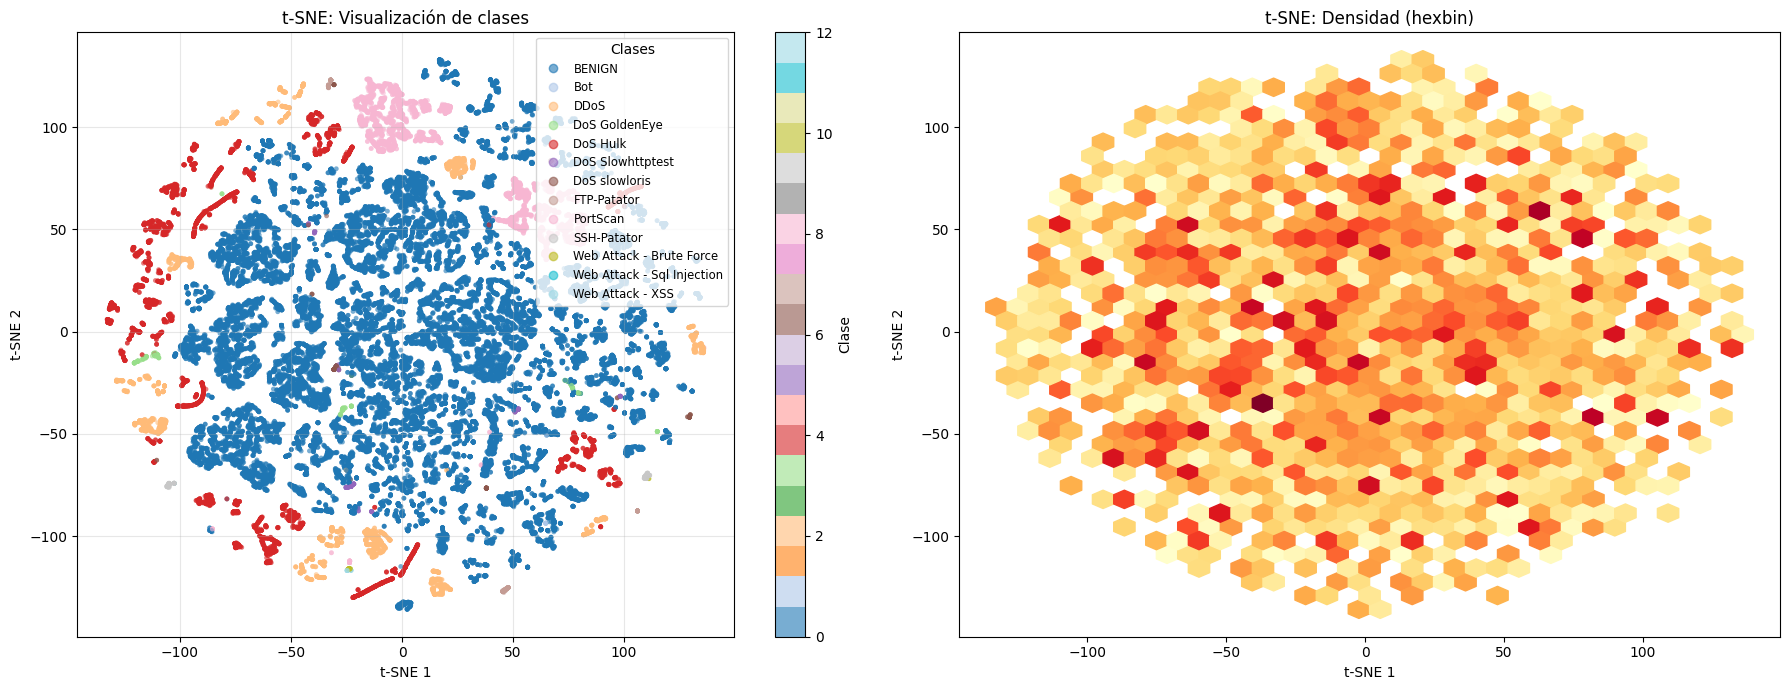


Distribución de clases (muestra usada):
  BENIGN: 37871
  Bot: 40
  DDoS: 2811
  DoS GoldenEye: 247
  DoS Hulk: 5061
  DoS Slowhttptest: 136
  DoS slowloris: 124
  FTP-Patator: 160
  PortScan: 3382
  SSH-Patator: 121
  Web Attack - Brute Force: 33
  Web Attack - Sql Injection: 1
  Web Attack - XSS: 13


In [13]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000,
    learning_rate='auto',
    init='random',
    verbose=1
)

X_tsne = tsne.fit_transform(X_tsne_scaled)

# Codificación para colorear
y_class = pd.Categorical(y_tsne).codes
class_names = pd.Categorical(y_tsne).categories

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

scatter = axes[0].scatter(
    X_tsne[:, 0], X_tsne[:, 1],
    c=y_class, cmap='tab20', alpha=0.6, s=12, edgecolors='none'
)

axes[0].set_title('t-SNE: Visualización de clases')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter, ax=axes[0], label='Clase')

# Mapa de densidad
axes[1].hexbin(X_tsne[:, 0], X_tsne[:, 1], gridsize=35, cmap='YlOrRd', mincnt=1)
axes[1].set_title('t-SNE: Densidad (hexbin)')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.tight_layout()

handles, _ = scatter.legend_elements()
unique_classes = np.unique(y_class)
legend_labels = [class_names[i] for i in unique_classes]

axes[0].legend(
    handles,
    legend_labels,
    title="Clases",
    loc="upper right",
    fontsize="small"
)

plt.show()

print("\nDistribución de clases (muestra usada):")
for i, class_name in enumerate(class_names):
    print(f"  {class_name}: {(y_class == i).sum()}")

# Top 10 caracteristicas más y menos importante y varianza dependiendo del tipo de caracteristica- PCA

In [ ]:
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedShuffleSplit

# Escalado para PCA
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X)

# Conserva 95% de varianza para el ranking global
pca_full = PCA(n_components=0.95, svd_solver="full", random_state=42)
X_pca_full = pca_full.fit_transform(X_scaled_pca)

# Importancia aproximada por feature
loadings = pca_full.components_
weights = pca_full.explained_variance_ratio_
importance = (np.abs(loadings).T @ weights)

imp_df = (
    pd.DataFrame({"feature": X.columns, "importance_pca": importance})
    .sort_values("importance_pca", ascending=False)
    .reset_index(drop=True)
)

top10 = imp_df.head(10)
bottom10 = imp_df.tail(10).sort_values("importance_pca", ascending=True)

print("Top 10 características MÁS importantes (PCA):")
print(top10.to_string(index=False))

print("\nTop 10 características MENOS importantes (PCA):")
print(bottom10.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].barh(top10["feature"][::-1], top10["importance_pca"][::-1], color="seagreen")
axes[0].set_title("Top 10 más importantes (PCA)")
axes[0].set_xlabel("Importancia")

axes[1].barh(bottom10["feature"][::-1], bottom10["importance_pca"][::-1], color="indianred")
axes[1].set_title("Top 10 menos importantes (PCA)")
axes[1].set_xlabel("Importancia")

plt.tight_layout()
plt.show()

# Submuestra estratificada para visualización 2D
n_viz = min(20_000, len(X))
if len(X) > n_viz:
    sss_viz = StratifiedShuffleSplit(n_splits=1, train_size=n_viz, random_state=42)
    idx_viz, _ = next(sss_viz.split(X_scaled_pca, y_multi))
    X_viz = X_scaled_pca[idx_viz]
    y_viz = y_multi.iloc[idx_viz]
else:
    X_viz = X_scaled_pca
    y_viz = y_multi

pca_2d = PCA(n_components=2, random_state=42)
emb_2d = pca_2d.fit_transform(X_viz)

y_codes = pd.Categorical(y_viz).codes
class_names = pd.Categorical(y_viz).categories

plt.figure(figsize=(9, 7))
sc = plt.scatter(
    emb_2d[:, 0], emb_2d[:, 1],
    c=y_codes, cmap="tab20", s=8, alpha=0.6, edgecolors="none"
)

plt.title("PCA 2D: Segmentación por clases")
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% var)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% var)")
plt.grid(alpha=0.2)

handles, _ = sc.legend_elements()
present = np.unique(y_codes)
labels = [class_names[i] for i in present]
plt.legend(handles, labels, title="Clases", loc="best", fontsize="small")

plt.show()

# Matriz de Correlacion

In [ ]:
import seaborn as sns

# Preparar datos numéricos
numeric_cols = [col for col in df.columns if col not in [
    'Label', 'Flow ID', 'Source IP', 'Destination IP', 'Timestamp',
    'label_binary', 'source_file'
]]

df_numeric = df[numeric_cols].select_dtypes(include=[np.number])
df_numeric = df_numeric.replace([np.inf, -np.inf], np.nan).dropna()

# Top 25 por varianza para que la visualización sea legible
top_features = df_numeric.var().sort_values(ascending=False).head(25).index
corr_matrix = df_numeric[top_features].corr()

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    cbar_kws={"shrink": 0.8},
    ax=ax
)
ax.set_title("Matriz de Correlación: Top 25 Features", fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*80)
print("Características Altamente Correlacionadas (r > 0.90)")
print("="*80)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) > 0.90:
            high_corr_pairs.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlación': round(corr_val, 4)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlación', key=abs, ascending=False)
    print(f"\nEncontrados {len(high_corr_df)} pares altamente correlacionados:")
    for idx, row in high_corr_df.iterrows():
        print(f"  {row['Feature 1']} <-> {row['Feature 2']}: r = {row['Correlación']}")
else:
    print("\nNo se encontraron pares con r > 0.90 en el top 25")

print("\n" + "="*80)
print("Características Relacionadas con Tamaño de Paquetes")
print("="*80)

size_keywords = ['packet', 'bytes', 'length', 'size', 'payload']
size_related = [col for col in df_numeric.columns if any(kw in col.lower() for kw in size_keywords)]

if size_related:
    print(f"\nCaracterísticas de tamaño encontradas ({len(size_related)}):")
    for col in sorted(size_related):
        print(f"  - {col}")
    
    # Correlaciones entre features de tamaño
    if len(size_related) > 1:
        size_corr = df_numeric[size_related].corr()
        print(f"\nCorrelaciones entre características de tamaño (r > 0.85):")
        for i in range(len(size_corr.columns)):
            for j in range(i+1, len(size_corr.columns)):
                corr_val = size_corr.iloc[i, j]
                if abs(corr_val) > 0.85:
                    print(f"  {size_corr.columns[i]} <-> {size_corr.columns[j]}: r = {round(corr_val, 4)}")
else:
    print("\nNo se encontraron características con palabras clave de tamaño")

# Preporcesado
1. __Agrupar valores de caracteristicas__. Si se considera necesario o interesante agrupar por rangos los valores de una categoría. Justificar la decisión adoptada.
2. __Gestionar missing values y duplicados__. (suprimir, imputación simple, imputación guiada, imputación informada…).Justificar la decisión adoptada.
3. __Gestionar outliers__. Detectar si existen y tomar la decisión de qué hacer con ellos aplicando las estrategias más habituales: análisis visual, IQR, Percentiles, Z-score, IsolationForest… Justificar la decisión adoptada.
4. __Escalar/Normalizar datos__. Las estrategias más habituales para aplicar son: estandarización, escalado mínimo-máximo, escalado robusto, escalado absoluto, escalado por la norma… Justificar la decisión adoptada.
5. __Windowing__ si el modelo a entrenar es temporal. 
6. __Seleccion de caracteristicas/Reduccion de dimensionalidad__. (PCA, Random Forest, etc.). Justificar la decisión adoptada.
7. __Split Train/Test/Validation__. Si hay desbalanceo, realizar un split estratificado por clases. Justificar la decisión adoptada.
    1. Se puede realizar undersampling y oversampling (SMOTE, ADASYN, etc.) para balancear el dataset. Justificar la decisión adoptada. Usar tecnicas adicionales de balanceo se evaluara positivamente. 